<a href="https://colab.research.google.com/github/Carlogui/IMEC_3345/blob/Tarea_4_Preparcial/Tarea4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<br>

<br>

<br>

<font color='black' align="center"><h1> </h1></font>

<font color='black'><h1 align="center">IMEC 3345 - Sistemas de Conversión de Energía</h1></font>

<font color='black'><h1 align="center">Profesor: Andres Gonzalez Mancera </h1></font>

<font color='black'><h1 align="center">Taller 4 Pre-parcial</h1></font>

<font color='black'><h1 align="center">Carlos Ernesto Upegui - 202213004</h1></font>

<br>

<br>

<font color='black'><center>Septiembre 24 2025<br>Segundo Semestre 2025 <br>Bogotá DC – Colombia </center><br></font>

In [ ]:
#Librerias para la tarea
import pandas as pd
import numpy as np
import os
from google.colab import drive
import os, glob, re, unicodedata
from pathlib import Path
import datetime
import matplotlib.pyplot as plt
from matplotlib.sankey import Sankey
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#Montar el drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Dirextorio Colab
BASE_DIR = Path(r"/content/drive/MyDrive/filescolab")

<strong><font color='black'><h1><left> Taller 4 Preparcial</left><h1></strong>


</font>

<em><font color='black'><left>Solucion Ejercicio 1</left></font></em>



In [4]:
A = {'C':12, 'H':1, 'O':16}       # masas atómicas

#Funcon
def kgCO2_por_kg(f):

    M = f.get('C',0)*A['C'] + f.get('H',0)*A['H'] + f.get('O',0)*A['O']

    return f.get('C',0)*44 / M

#Lista de combustibles
comb = {
    'Gasolina C8H18': ({'C':8,'H':18}, 44.0),

    'Carbón C'      : ({'C':1},        30.0),

    'Madera CH2O'   : ({'C':1,'H':2,'O':1}, 10.0),

    'Butano C4H10' : ({'C':4,'H':10}, 50.0),
}
#Resultados
print("RESULTADOS")

for name, (f, LHV) in comb.items():

    kgCO2_kg = kgCO2_por_kg(f)

    kgCO2_MJ = kgCO2_kg / LHV

    print(f"{name}: {kgCO2_kg:.4f} kgCO2/kg,  {kgCO2_MJ:.5f} kgCO2/MJ  ({kgCO2_MJ*1e3:.2f} g/MJ)")


RESULTADOS
Gasolina C8H18: 3.0877 kgCO2/kg,  0.07018 kgCO2/MJ  (70.18 g/MJ)
Carbón C: 3.6667 kgCO2/kg,  0.12222 kgCO2/MJ  (122.22 g/MJ)
Madera CH2O: 1.4667 kgCO2/kg,  0.14667 kgCO2/MJ  (146.67 g/MJ)
Butano C4H10: 3.0345 kgCO2/kg,  0.06069 kgCO2/MJ  (60.69 g/MJ)


<em><font color='black'><left> Solución Ejercicio 2</left></font></em>



In [3]:
#valores conocidos
cp, gam = 1.004, 1.4

T1, T3, rp = 300.0, 1200.0, 8.0

eta_c, eta_t = 0.92, 0.92

#ecuaciones
n = (gam-1)/gam

T2s = T1*rp**n;  T2 = T1 + (T2s - T1)/eta_c

T4s = T3/rp**n;  T4 = T3 - eta_t*(T3 - T4s)

w_c = cp*(T2-T1); w_t = cp*(T3-T4)

w_net = w_t - w_c; q_in = cp*(T3-T2)

eta_th = w_net/q_in

E_elec_GJ = 700e6*3.6/1e3

E_shaft = E_elec_GJ/0.98

E_heat  = E_shaft/eta_th

E_fuel  = E_heat/0.88

costUSD = 10*E_fuel

CO2_kg  = 55.0*E_fuel

def fnum(x, nd=2):  return f"{x:,.{nd}f}"

def fusd(x):        return f"${x:,.0f}"

MtCO2_year = CO2_kg / 1e9

tCO2_per_mln_kWh = (CO2_kg / 700e6) * 1e6 / 1000  # t por millón de kWh

#Resuultados
print("RESULTADOS")
print(f"• Eficiencia térmica del ciclo Brayton: {eta_th*100:.2f} %")
print(f"• Energía de combustible requerida al año (LHV): {fnum(E_fuel)} GJ/año")
print(f"• Costo anual del gas (10 USD/GJ): {fusd(costUSD)} por año")
print(f"• Emisiones de CO2 al año (factor 55 kg/GJ): {fnum(MtCO2_year,3)} MtCO2/año")
print(f"• Emisiones específicas: {fnum(tCO2_per_mln_kWh,1)} tCO2 por millón de kWh")


RESULTADOS
• Eficiencia térmica del ciclo Brayton: 36.19 %
• Energía de combustible requerida al año (LHV): 8,074,626.96 GJ/año
• Costo anual del gas (10 USD/GJ): $80,746,270 por año
• Emisiones de CO2 al año (factor 55 kg/GJ): 0.444 MtCO2/año
• Emisiones específicas: 634.4 tCO2 por millón de kWh


<em><font color='black'><left> Solución Ejercicio 3</left></font></em>



In [ ]:
#valores conocidos
area = 110_000            # ft^2

E_int = 115               # kBTU/ft^2·año

precio = 8.50             # USD/MMBtu

fe_CO2 = 117              # lb CO2 / MMBtu

reduccion = 0.20          # 20%

vida = 20                 # años

tasa = 0.05               # 5%

capex = 300_000           # USD
incentivo = 0.25          # 25% del CAPEX


E_base_MMBtu = area * E_int / 1000                 # MMBtu/año

E_ahorro = reduccion * E_base_MMBtu                # MMBtu/año

CO2_lb = E_ahorro * fe_CO2                         # lb/año

CO2_t_short = CO2_lb / 2000                        # ton corta/año

CO2_t_metric = CO2_lb / 2204.62                    # t métrica/año

ahorro_USD = E_ahorro * precio                     # USD/año

FA = (1 - (1 + tasa)**(-vida)) / tasa              # factor anualidad

PV_ahorros = ahorro_USD * FA                       # USD

VPN_sin = PV_ahorros - capex                       # USD

VPN_con = PV_ahorros - capex * (1 - incentivo)     # USD

def fnum(x):  return f"{x:,.2f}"

def fusd(x):  return f"${x:,.0f}"

def fton(x):  return f"{x:,.1f}"

#resultados
print("RESULTADOS ")
print(f"• Energía anual base del edificio: {fnum(E_base_MMBtu)} MMBtu/año")
print(f"• Ahorro de energía por la medida (20%): {fnum(E_ahorro)} MMBtu/año")
print(f"• CO2 evitado por año: {fnum(CO2_lb)} lb/año = {fton(CO2_t_short)} ton cortas/año = {fton(CO2_t_metric)} t métricas/año")
print(f"• Ahorro económico anual por menor consumo de gas: {fusd(ahorro_USD)}/año")
print(f"• Valor presente de los ahorros (20 años, 5%): {fusd(PV_ahorros)}")
print(f"• VPN SIN incentivo (CAPEX = {fusd(capex)}): {fusd(VPN_sin)}")
print(f"• VPN CON incentivo del 25% (CAPEX neto = {fusd(capex*(1-incentivo))}): {fusd(VPN_con)}")


RESULTADOS 
• Energía anual base del edificio: 12,650.00 MMBtu/año
• Ahorro de energía por la medida (20%): 2,530.00 MMBtu/año
• CO2 evitado por año: 296,010.00 lb/año = 148.0 ton cortas/año = 134.3 t métricas/año
• Ahorro económico anual por menor consumo de gas: $21,505/año
• Valor presente de los ahorros (20 años, 5%): $268,000
• VPN SIN incentivo (CAPEX = $300,000): $-32,000
• VPN CON incentivo del 25% (CAPEX neto = $225,000): $43,000


<em><font color='black'><left> Solución Ejercicio 4</left></font></em>



<font color='black'><strong><em><left> 1. Explique, con fundamentos termodinámicos, por qué el aumento de GEI
provoca cambio climático. </left></em></strong><br><br>
El aumento de GEI provoca el cambio climatico porque absorben radiación del sol
que rebota en la tierra. La Tierra se equilibra cuando la potencia solar absorbida = la potencia térmica emitida. Los GEI (CO₂, CH₄, N₂O, H₂O etc.) absorben la radiación infrarroja saliente, incrementan el radiative forcing (ERF) y desequilibran el balance. Por lo tanto, la superficie debe calentarse hasta restablecerlo a una temperatura mayor. Esto se puede ver con el aumento de CO₂, que pasó de ≈278 ppm a ≈423 ppm y la T media subió 1.5 °C en dos siglos, lo qeu es coherente con ese forzamiento radiativo.
<br><br><strong><em><left> 2. Compare la matriz eléctrica y la matriz energética primaria de Colombia frente
al promedio mundial.</left></em></strong>

</font>

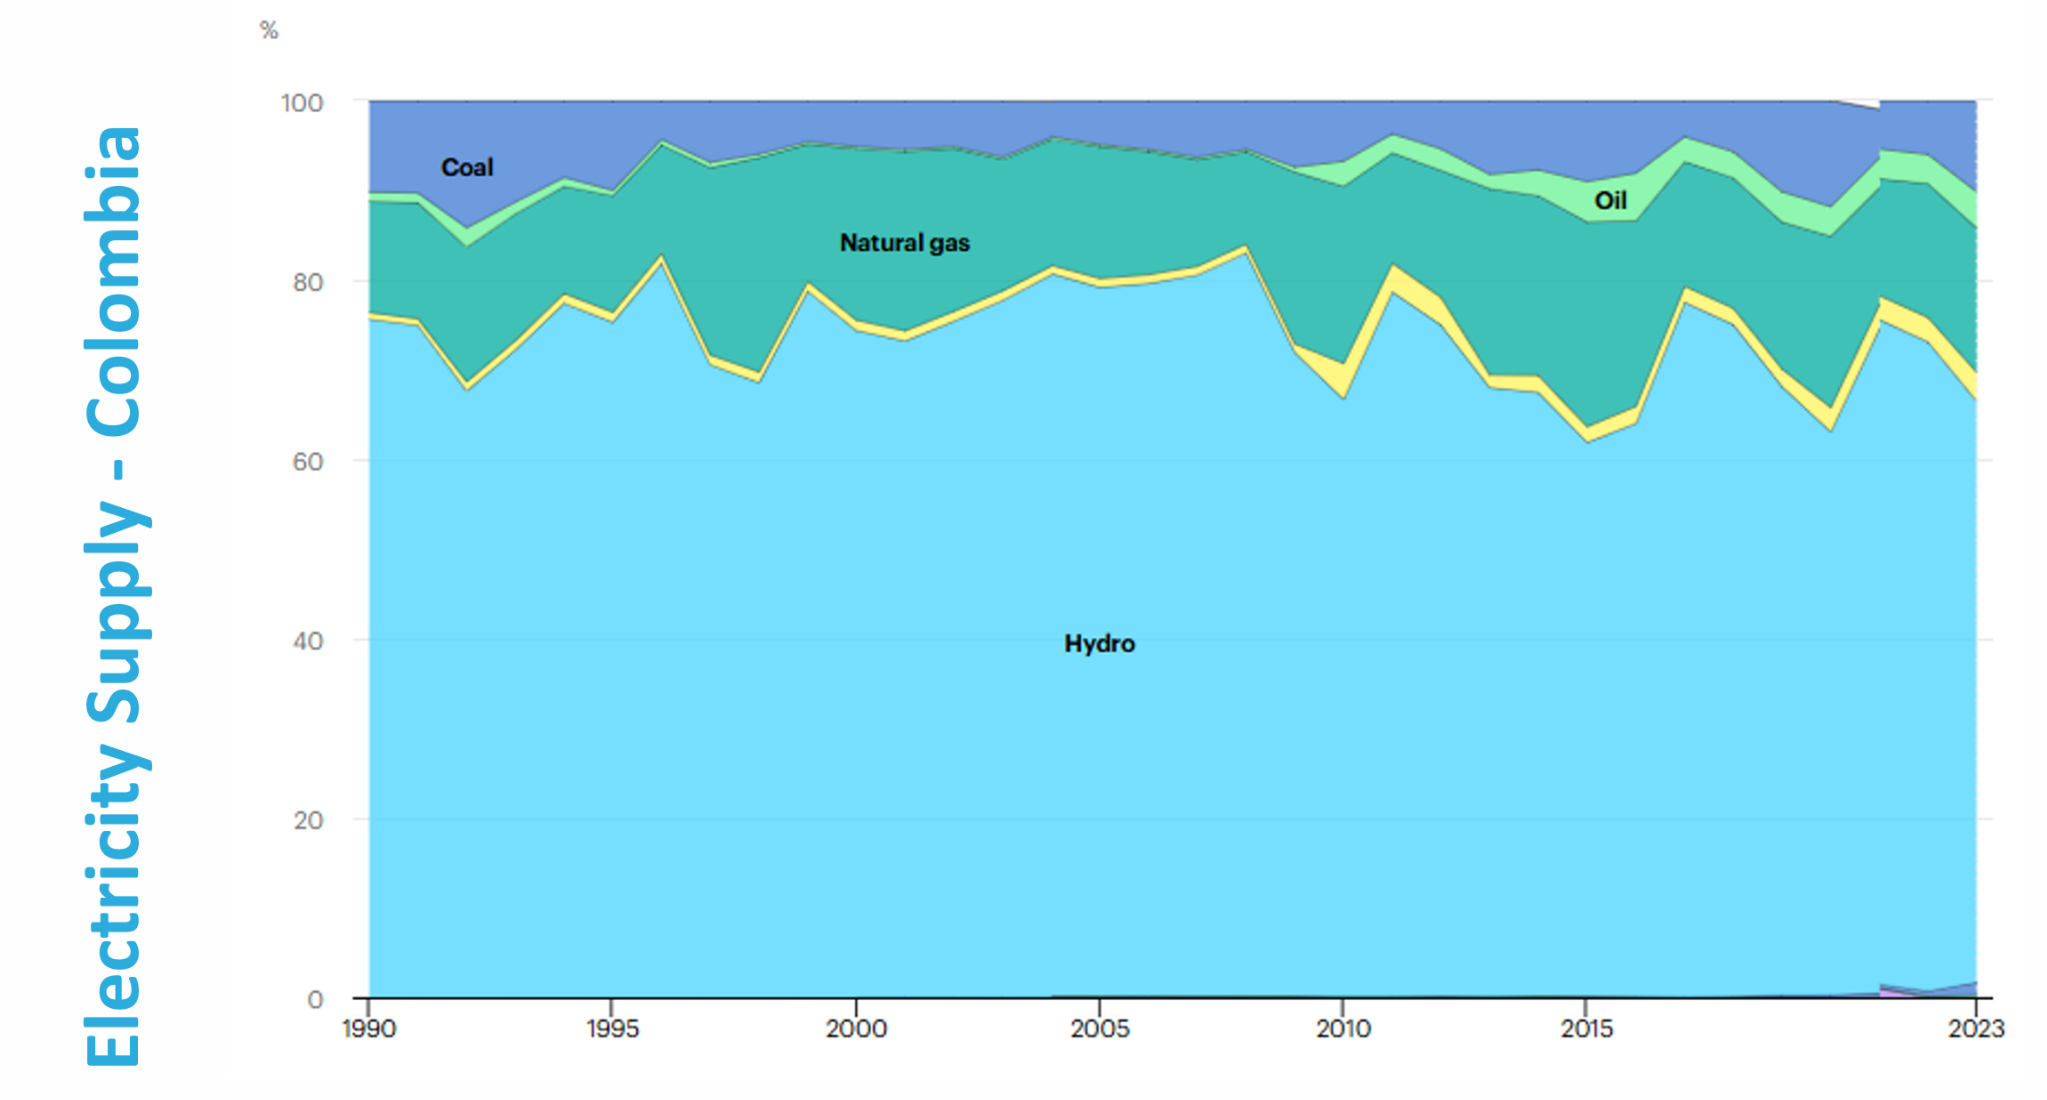

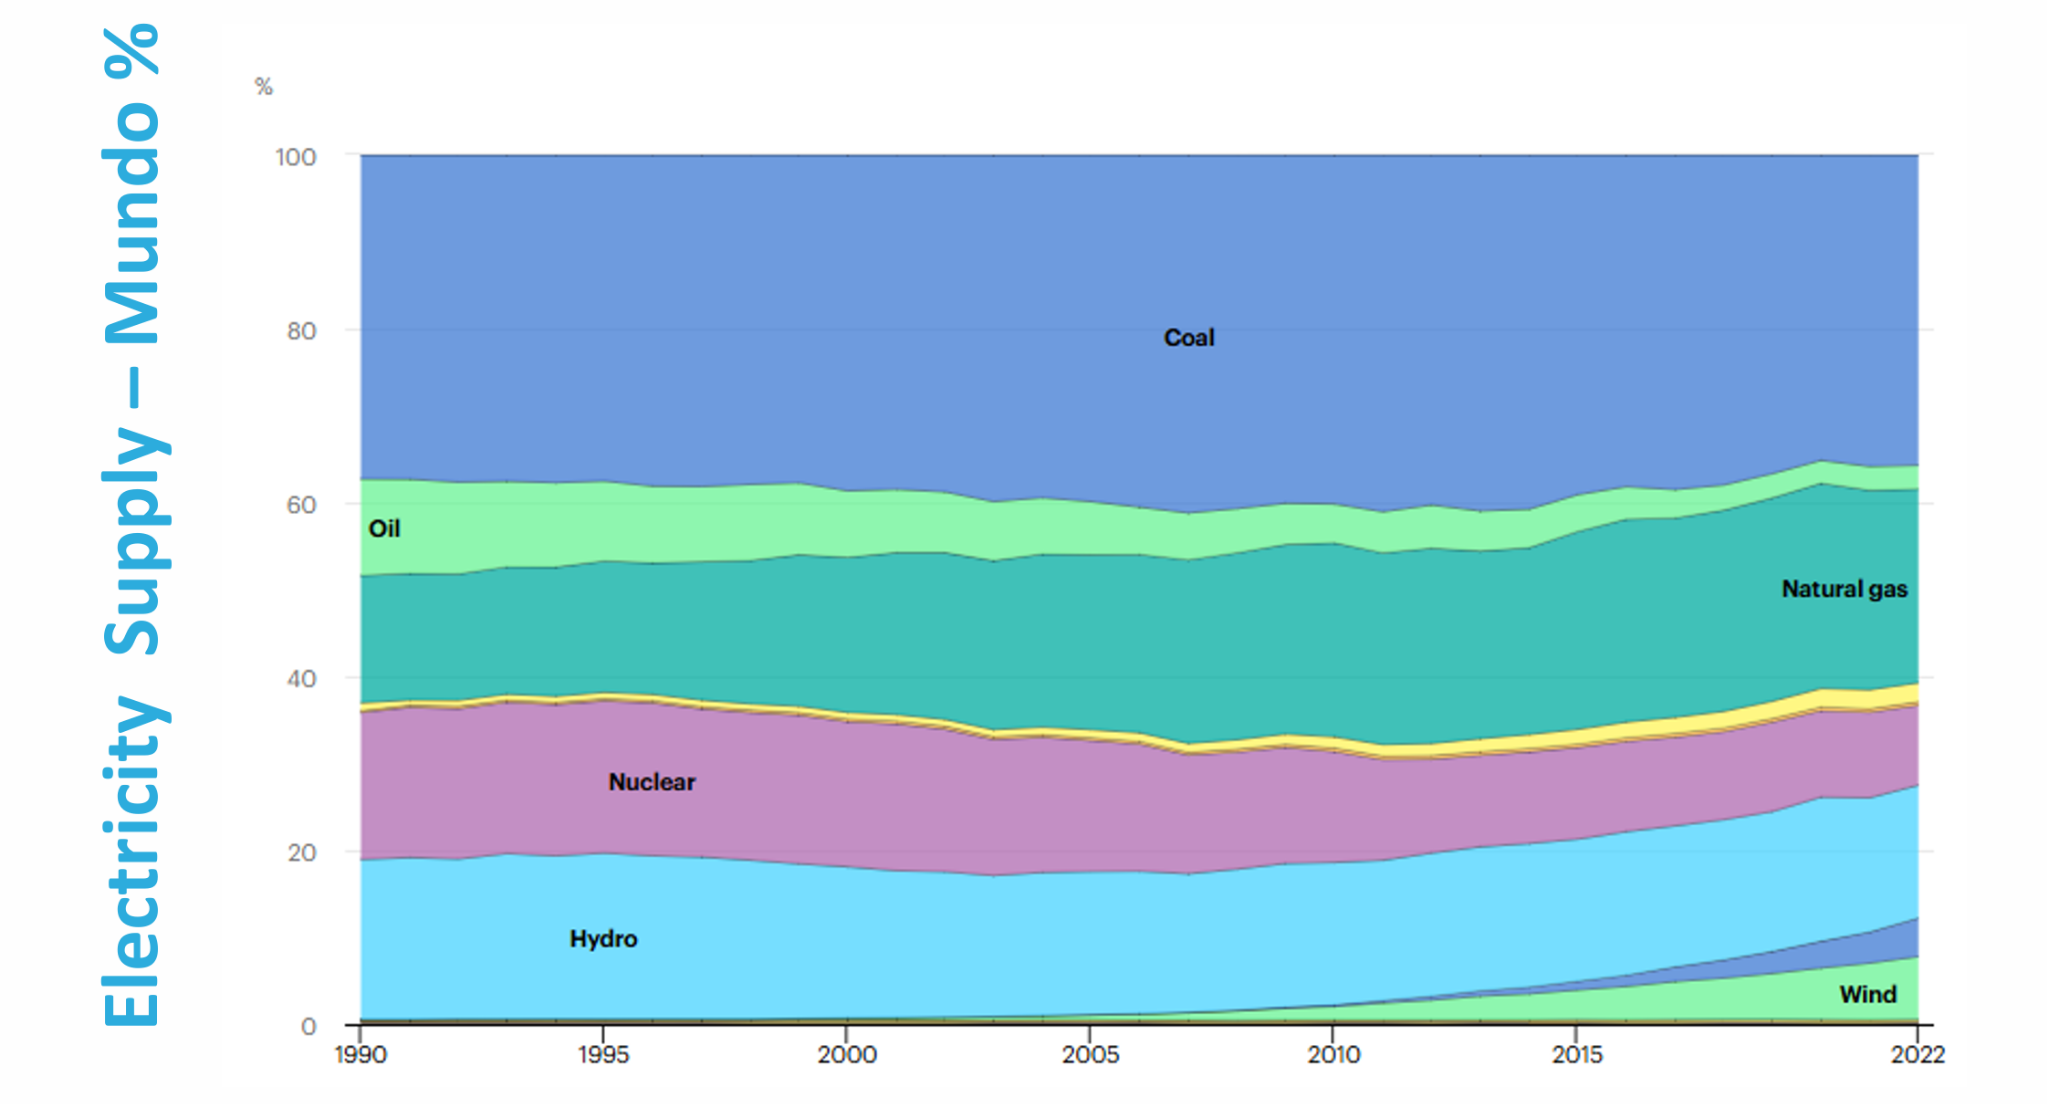

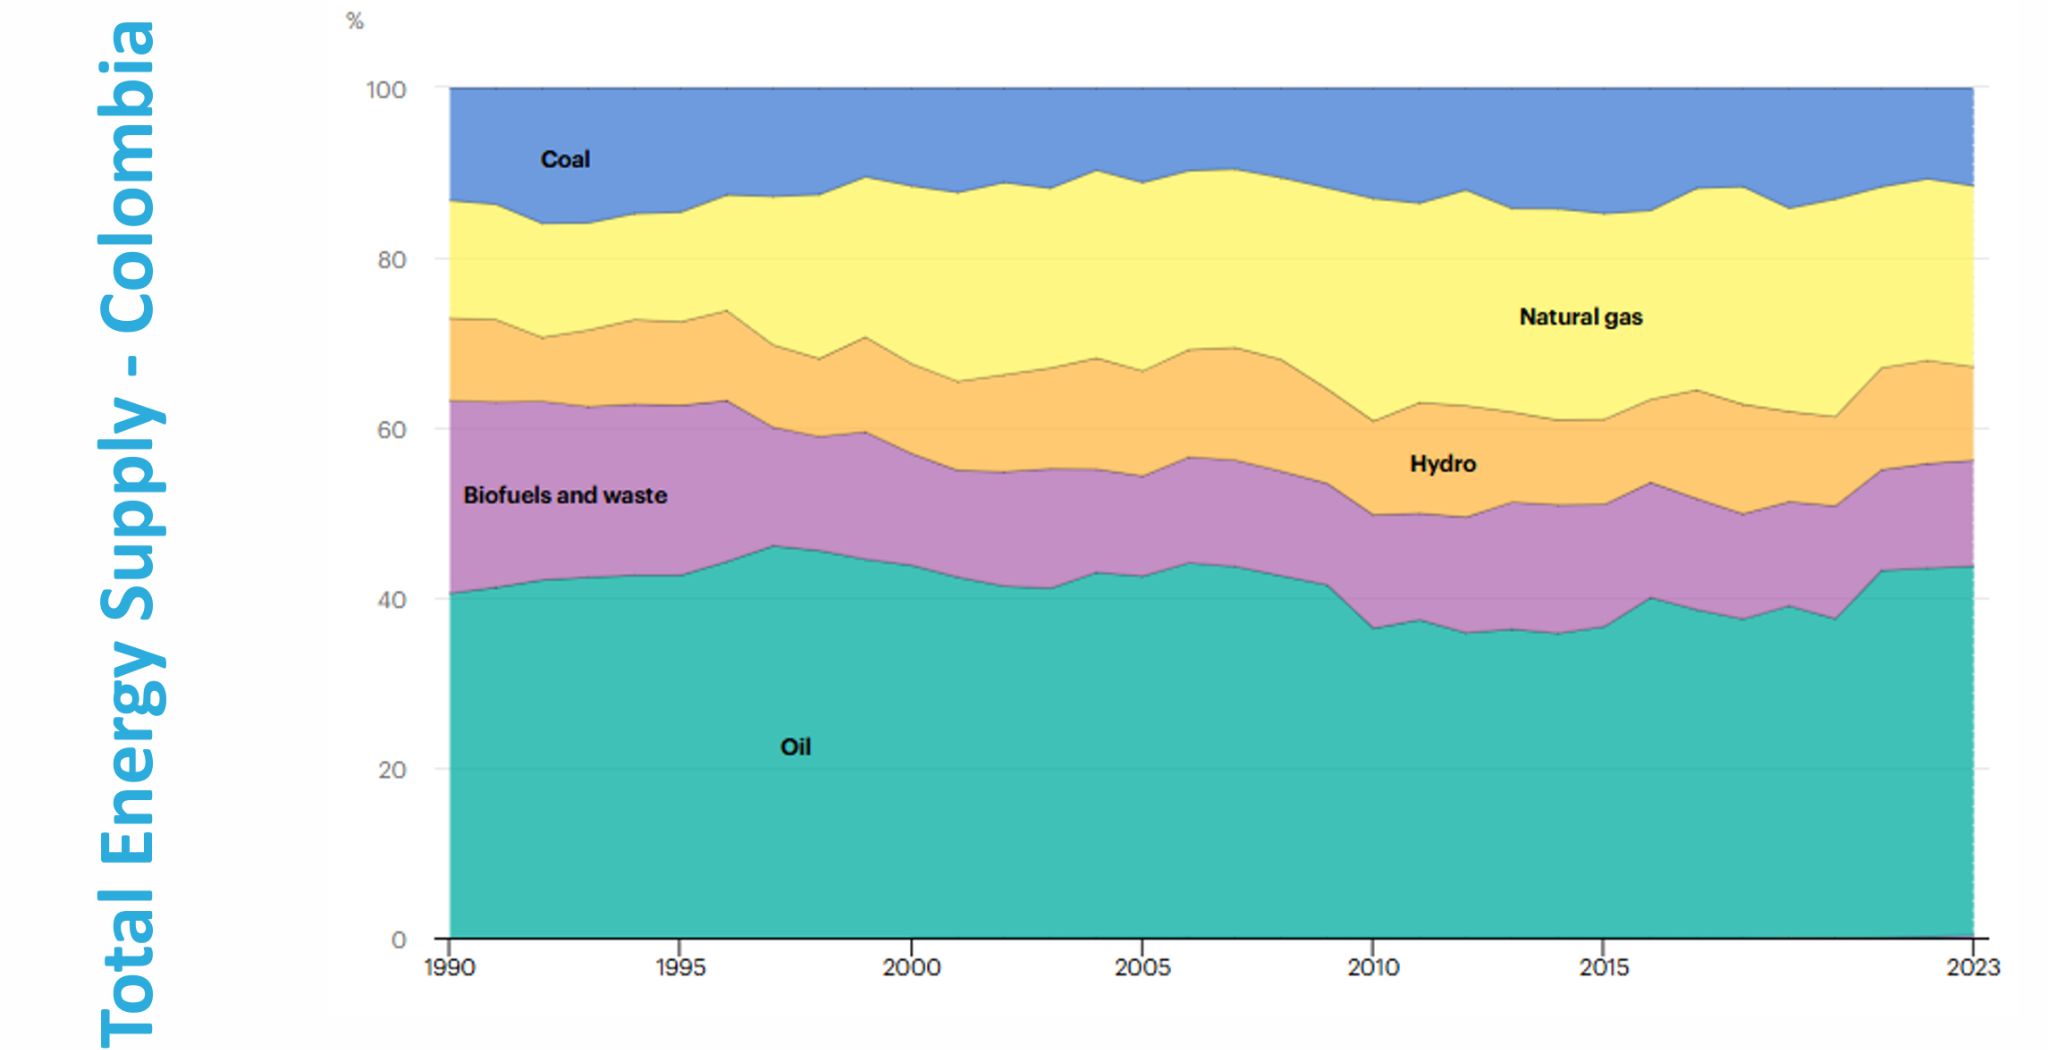

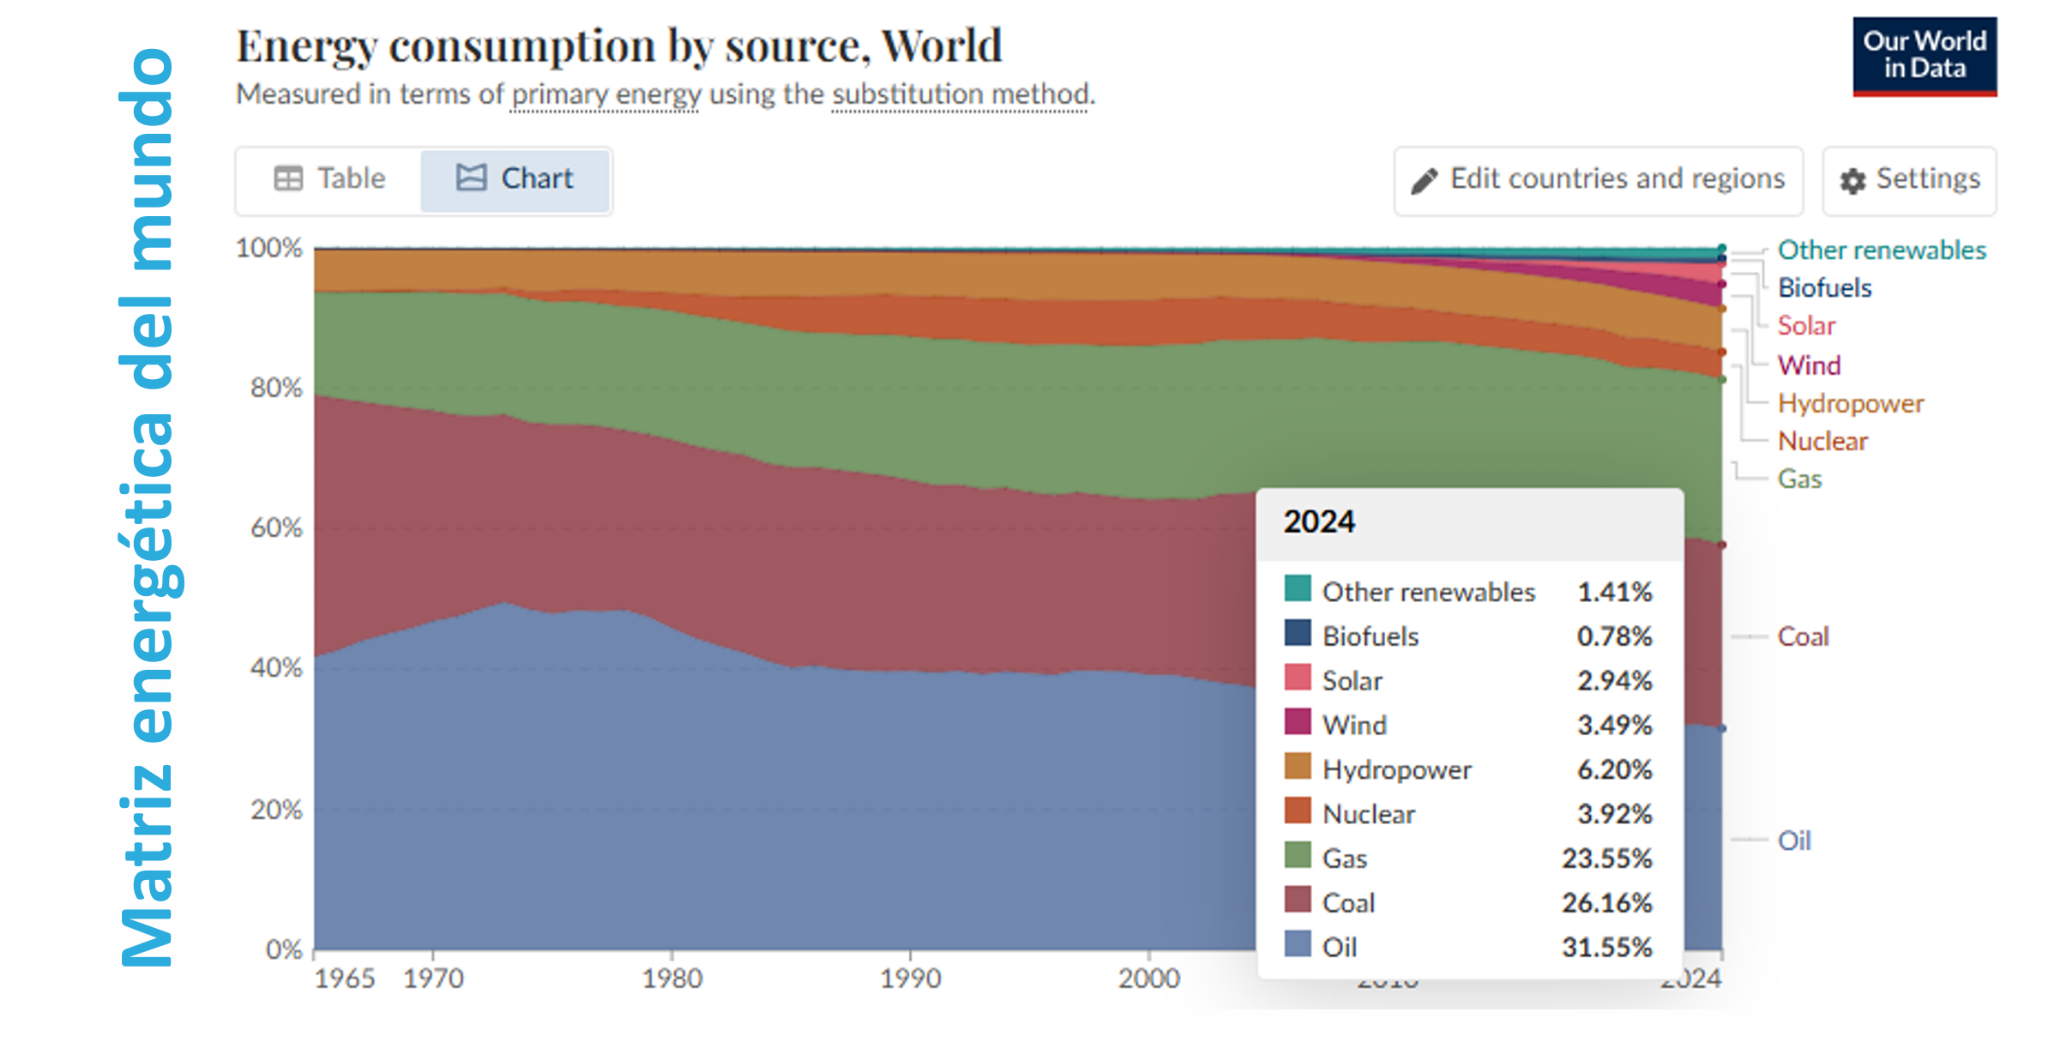

<font color='black'><em><strong>Matriz eléctrica</strong></em><br></font>
<ul>
<font color='black'>
<li><strong>Colombia:</strong> Predomina de manera mayoritaria la hidroelectricidad, rondando entre ≈70–85% del suministro eléctrico desde 1990 hasta la actualidad. El resto se cubre sobre todo con gas natural y en menor medida carbón y oil, eólica/solar aparecen al final y aún son pequeñas.<br></li>
<li><strong>Mundo:</strong> La electricidad sigue siendo mayoritariamente de combustibels fosiles, con carbón como fuente más grande y gas natural en segundo lugar, la hidro ocupa un ≈20, nuclear disminuyendo del ≈18%, y eólica y solar crecen bastante pero todavía son mintoritarias.</li>
</ul>
</font>

<font color='black'><em><strong>Matriz energética primaria</strong></em><br></font>
<ul>
<font color='black'>
<li><strong>Colombia:</strong> La oferta primaria mayoritariamente de combustibles fosiles, pero un poco distinto al mundial: hay un mayor peso relativo de petróleo y gas natural, carbón más bajo que el promedio global, y hay una mayor representación de biocombustibles/residuos e hidro ≈20, pero sigue siendo menor que con los fosiles.<br></li>
<li><strong>Mundo:</strong> Predomina aún lo fósil, petróleo (≈32%), carbón (≈26%), gas natural (≈24%). Las renovables como solar y eólica apenas superan el 6–7% en. La hidroeléctrica es ~6% y la nuclear ~4%. El mundo sigue en una matriz energética ≈80% fósil, con lenta penetración de renovables.</li>
</ul>
</font>
<font color='black'>

Hablando de la matriz electrica, Colombia tiene una intensidad de carbono mucho menor que el promedio mundial gracias al peso de la hidro, pero es más vulnerable a sequías/El Niño y depende de gas como respaldo. En cuanto a la matriz energética, aunque la electricidad de Colombia es limpia, su matriz energética total (transporte, calor, industria) se parece al mundo en que sigue dominada por petróleo + gas, solo que con menos carbón y algo más de bioenergía/hidro que el promedio global.
</font>

<font color='black'><strong><em><left> 3. Enumere las rutas principales de descarbonización sugeridas por el IPCC
(electrificar, sustituir vectores, atacar HtA, CDR) y evalúe su impacto en los
ciclos (corto y largo) de carbono  
provoca cambio climático. </left></em></strong><br><br>
<ol>
<li> Electrificación </li>
<ul>
<font color='black'>
<li>Consiste en desplazar consumos fósiles (transporte, calefacción, procesos industriales) hacia electricidad.</li>
<li>Impacto en el ciclo corto: reducción inmediata de emisiones si la electricidad proviene de fuentes bajas en carbono (ej. hidro en Colombia).</li>
<li>Impacto en el ciclo largo: al completarse la descarbonización de la red eléctrica, permite eliminar casi totalmente las emisiones de sectores actualmente fósiles.</li>
</font>
</ul>
<li>Sustituir vectores energéticos</li>
<ul>
<font color='black'>
<li>Uso de hidrógeno limpio, biocombustibles sostenibles, e-fuels o amoníaco en sectores difíciles de electrificar (aviación, transporte marítimo, siderurgia)</li>
<li>Corto plazo: puede disminuir emisiones parciales usando biocombustibles o H₂ azul con CCS.</li>
<li>Largo plazo: con H₂ verde y e-fuels producidos con renovables, se eliminan las emisiones en sectores hoy “duros de abatir”.</li>
</font>
</ul>
<li>Atacar sectores Hard-to-Abate (HtA)</li>
<ul>
<font color='black'>
<li>Industrias intensivas en calor y procesos (cemento, acero, químicos, aviación, marítimo).</li>

<li>Corto plazo: mejoras de eficiencia, captura en procesos, mezclas de combustibles.</li>

<li>Largo plazo: tecnologías disruptivas (acero con H₂, cementos alternativos, electrificación de hornos) y despliegue de CCS.</li>

<li>Impacto directo: permite reducir emisiones de procesos inevitables, no sólo de combustión.</li>
</font>
</ul>
<li>CDR (Carbon Dioxide Removal)</li>
<ul>
<font color='black'>
<li>Incluye reforestación, manejo de suelos, BECCS, DACCS, meteorización acelerada.</li>

<li>Corto plazo: contribución marginal; escalamiento aún limitado.</li>

<li>Largo plazo: indispensable para remover CO₂ residual, balancear emisiones inevitables y reducir la concentración atmosférica acumulada.</li>

<li>Impacta el ciclo largo de carbono: devuelve carbono al subsuelo/bosques, estabilizando el stock atmosférico.</li>
</ol><br>

<font color='black'><strong><em><left> 4. ¿Cuál es la diferencia entre CCS y CDR? ¿En qué sectores se puede aplicar cada una? </left></em></strong></font>

La diferencia central entre CCS y CDR está en el momento y el lugar en que actúan sobre el carbono. El CCS (Carbon Capture and Storage) se aplica en fuentes puntuales, como termoeléctricas, cementeras, acerías o refinerías, y su función es evitar que el CO₂ emitido en los procesos industriales y de combustión llegue a la atmósfera, capturándolo y almacenándolo en formaciones geológicas o acuíferos salinos. En cambio, el CDR (Carbon Dioxide Removal) busca quitar el CO₂ que ya se está acumulado en la atmósfera o en el ciclo corto del carbono, a través de medidas como la reforestación, la bioenergía con captura (BECCS), la captura directa del aire (DACCS) o procesos de mineralización. Por eso, el CCS se aplica principalmente en sectores industriales pesados y en generación fósil que aún persiste, mientras que el CDR se implementa en el uso del suelo, en proyectos bioenergéticos y en tecnologías de captura difusa, siendo bastante importantes para compensar las emisiones residuales y lograr objetivos de neutralidad o incluso emisiones negativas en el largo plazo.
<br><br>
<font color='black'><strong><em><left> 5. Compare las tecnologías de CCS en energía (post-combustión, pre-combustión y
oxyfuel) según factores técnicos, económicos, y ambientales y recomiende cuál
ruta sería más adecuada para Colombia.  </left></em></strong></font><br><br>
<strong>Post-combustión</strong> <br>
<strong>Técnico:</strong> Se instala en la corriente de gases de calderas/turbinas; 85–95% de captura es habitual. Es la única opción “retrofit” para plantas existentes (carbón o gas). Penalización energética moderada-alta (≈2.5–4 GJ/tCO₂ en calor/vapor equivalente; +3–8 puntos de consumo auxiliar). Requiere control previo de SOx/NOx/partículas para proteger el solvente.
<br><strong>Económico:</strong> CAPEX medio (absorbedor + desorbedor + equilibrio térmico) y OPEX relevante por reposición de solvente y vapor de regeneración; coste nivelado típico intermedio entre las tres rutas. Escala bien por trenes modulares.
<br><strong>Ambiental:</strong> Posible slip de aminas y subproductos (gestión con pulido y buenas prácticas). Demanda de agua para enfriamiento. CO₂ de alta pureza (≥99%) para compresión y transporte. <br><br>
<strong>Pre-combustión</strong> <br>
<strong>Técnico:</strong> Captura antes de quemar; el CO₂ está a alta presión y mayor concentración, lo que facilita su separación (membranas/PSA/solventes físicos). Requiere nueva planta tipo IGCC (carbón) o reformado de gas para H₂; no es retrofit simple para parques existentes. Penalización eléctrica menor que post-combustión, pero complejidad del tren químico mayor.
<br><strong>Económico:</strong> CAPEX alto por la propia conversión a H₂ y equipos de alta presión; atractivo si se va a producir hidrógeno azul para múltiples usos (energía + industria) o si se construye “greenfield”.
<br><strong>Ambiental:</strong> corriente de CO₂ muy pura y a presión; baja emisión de contaminantes de combustión porque finalmente se quema H₂.
<br><br>
<strong>Oxicombustión</strong><br>
<strong>Técnico:</strong> Combustión con O₂ en vez de aire; los gases son CO₂+H₂O, simplificando la captura. Necesita ASU (Air Separation Unit) de gran consumo eléctrico y re-circulación de gases para controlar temperatura. Es válido para calderas nuevas o reconversiones profundas de carbón.<br>
<strong>Económico:</strong> CAPEX alto (ASU + caldera adaptada) y OPEX dominado por el consumo de la ASU, es competitivo sólo en escalas grandes y donde se justifique una planta nueva.<br>
<strong>Ambiental:</strong> Capturas >95% factibles; menos NOx (sin N₂ en la zona de combustión), pero mayor uso energético aguas arriba por el O₂.
</font>